In [4]:
import pandas as pd 
import numpy as np 

#use for qq plot
import scipy.stats as stats 

import matplotlib.pyplot as plt 
import seaborn as sns 

from sklearn.model_selection import train_test_split 
from sklearn.metrics import accuracy_score 

from sklearn.model_selection import cross_val_score 

from sklearn.linear_model import LogisticRegression 
from sklearn.tree import DecisionTreeClassifier 

from sklearn.preprocessing import FunctionTransformer 
from sklearn.compose import ColumnTransformer



In [6]:
df=pd.read_csv('train.csv',usecols=['Age','Fare','Survived'])

In [7]:
df

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500
...,...,...,...
886,0,27.0,13.0000
887,1,19.0,30.0000
888,0,NaN,23.4500
889,1,26.0,30.0000


In [11]:
df.isnull().sum()

Survived    0
Age         0
Fare        0
dtype: int64

In [10]:
df['Age'].fillna(df['Age'].mean(),inplace=True)

In [12]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    df.drop('Survived', axis=1),
    df['Survived'],
    test_size=0.2,
    random_state=42
)

In [18]:
X_train.head()

,Age,Fare
331,45.5,28.5000
733,23.0,13.0000
382,32.0,7.9250
704,26.0,7.8542
813,6.0,31.2750


C:\Users\ansh0\AppData\Local\Temp\ipykernel_28464\2474531785.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train['Age'])


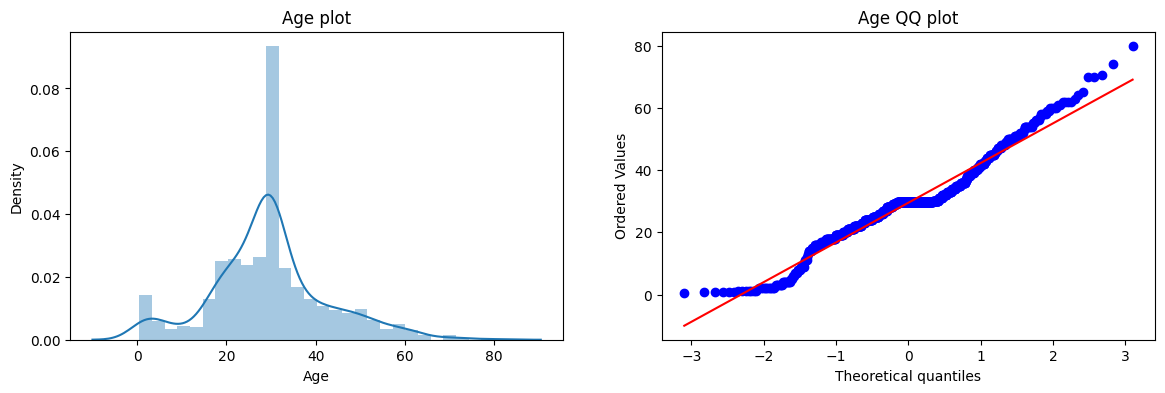

In [21]:


plt.figure(figsize=(14,4))
plt.subplot(121)
sns.distplot(X_train['Age'])
plt.title('Age plot')

#usiong qq plot

plt.subplot(122)
stats.probplot(X_train['Age'],dist="norm",plot=plt)
plt.title('Age QQ plot')

plt.show()

C:\Users\ansh0\AppData\Local\Temp\ipykernel_28464\2981780686.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train['Fare'])


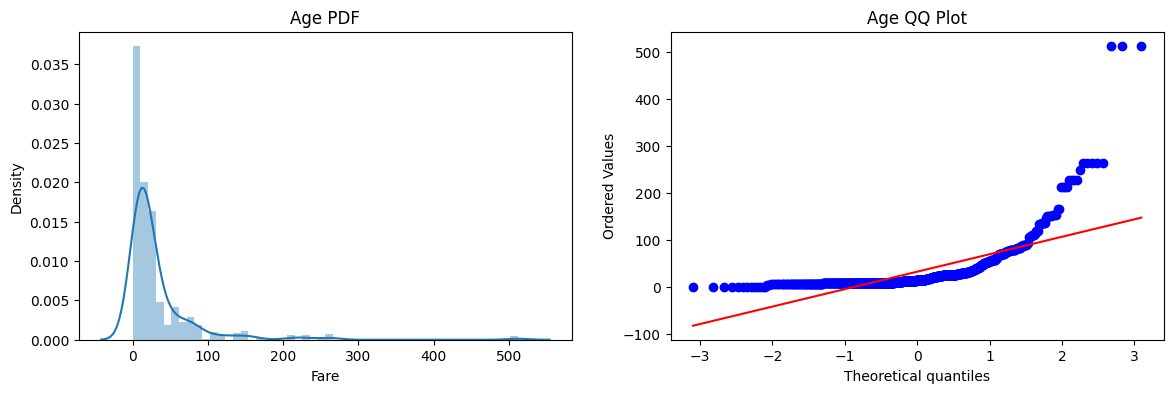

In [22]:
plt.figure(figsize=(14,4))
plt.subplot(121)
sns.distplot(X_train['Fare'])
plt.title('Age PDF')

plt.subplot(122)
stats.probplot(X_train['Fare'], dist="norm", plot=plt)
plt.title('Age QQ Plot')

plt.show()

In [24]:
clf=LogisticRegression() 
clf2=DecisionTreeClassifier() 



In [28]:
clf.fit(X_train,y_train) 
clf2.fit(X_train,y_train) 

y_pred=clf.predict(X_test) 
y_pred1=clf2.predict(X_test) 

print("Accuract of LR" ,accuracy_score(y_test,y_pred))
print("Accuract of DT" ,accuracy_score(y_test,y_pred1))

Accuract of LR 0.6480446927374302
Accuract of DT 0.6703910614525139


In [29]:
trf=FunctionTransformer(func=np.log1p)

In [31]:
X_train_transformed=trf.fit_transform(X_train) 
X_test_transformed=trf.fit_transform(X_test)

In [36]:
clf.fit(X_train_transformed,y_train)
clf2.fit(X_train_transformed,y_train) 

y_pred=clf.predict(X_test_transformed)
y_pred1=clf2.predict(X_test_transformed)

print("Accuracy of LR",accuracy_score(y_test,y_pred))
print("Accuracy of DT",accuracy_score(y_test,y_pred1))


Accuracy of LR 0.6815642458100558
Accuracy of DT 0.6759776536312849
